In [1]:
!pip install -q openai
!pip install tqdm

In [2]:
!head -10 /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/dev.en > dev10.en

In [3]:
!wget https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/decoder_oAI_translate.py



--2026-05-04 11:37:17--  https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/decoder_oAI_translate.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11338 (11K) [text/plain]
Saving to: ‘decoder_oAI_translate.py’

decoder_oAI_transla 100%[===================>]  11.07K  --.-KB/s    in 0s      

2026-05-04 11:37:17 (51.0 MB/s) - ‘decoder_oAI_translate.py’ saved [11338/11338]



# Set up a Secret key for Groq

## Create an account and key 

Create an account and generate a key at https://console.groq.com/home

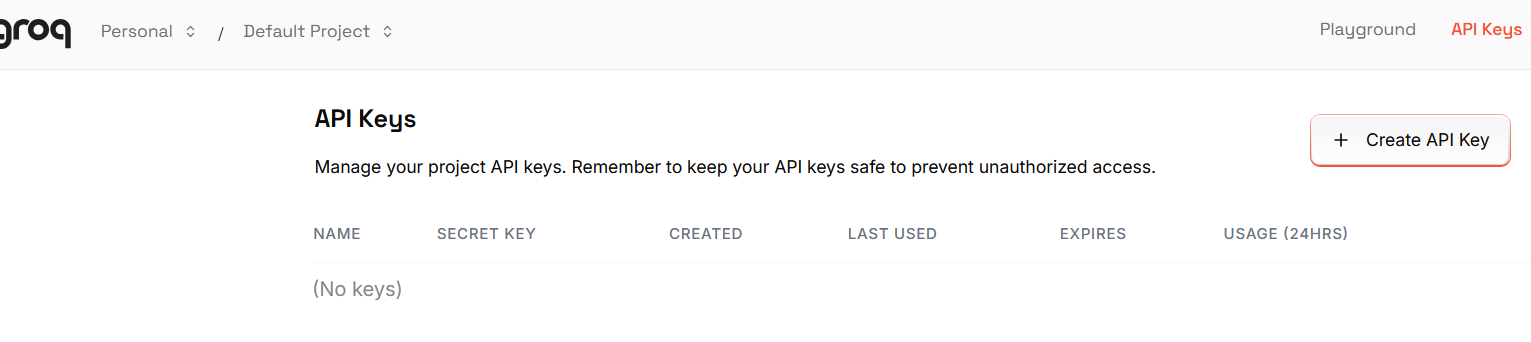
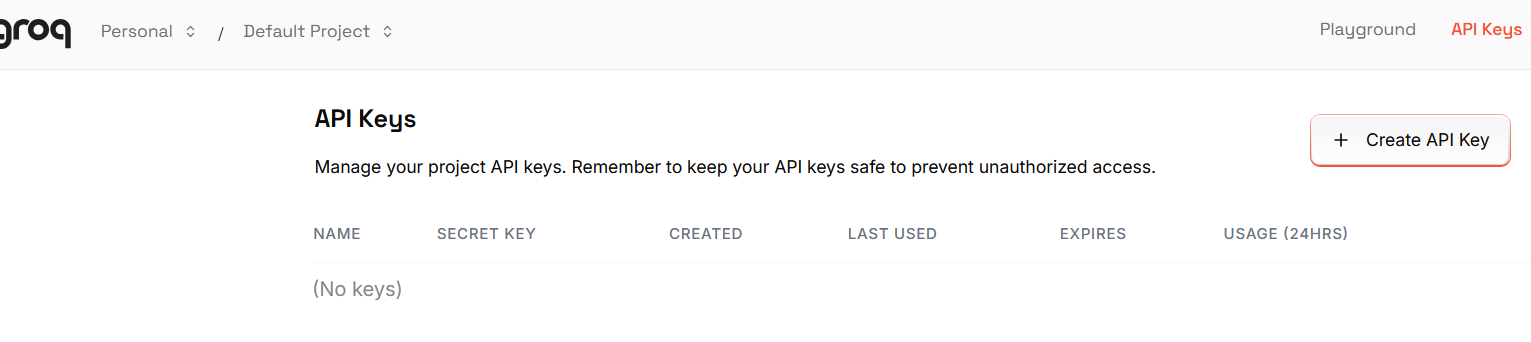

## Add key to Kaggle

`Add-ons -> Secrets -> Add Secret`

Name key: `groq`


In [4]:
from kaggle_secrets import UserSecretsClient
secret_label = "groq"
groq = UserSecretsClient().get_secret(secret_label)

In [5]:
!python decoder_oAI_translate.py \
  --input dev10.en \
  --output dev10.groq.nl \
  --source-lang English \
  --target-lang Dutch \
  --model llama-3.3-70b-versatile \
  --base-url https://api.groq.com/openai/v1 \
  --batch-size 4 \
  --temperature 0 \
  --progress \
  --show-translations \
  --show-n 1 \
  --kaggle-secret groq

--- Batch 1 ---
SRC: Nobody reads about my country .
TGT: Niemand leest over mijn land.

--- Batch 2 ---
SRC: Betty drives fast .
TGT: Betty rijdt snel.

--- Batch 3 ---
SRC: Tom thought Mary was cute .
TGT: Tom dacht dat Mary schattig was .

Translating: 100%|█████████████████████████████| 3/3 [00:01<00:00,  1.83batch/s]
[info] finished, wrote output to dev10.groq.nl
